<div style='color: #216969;
           background-color: #EAF6F6;
           font-size: 200%;
           border-radius:15px;
           text-align:center;
           font-weight:600;
           border-style: solid;
           border-color: dark green;
           font-family: "Cambria";'>
Ridge Regularization
<a class="anchor" id="1"></a> 

In [1]:
# Data Loading
import pandas as pd
import numpy as np
df= pd.read_csv("../data/Students_Grading_Dataset.csv")

![](../../imgs/featureEngin.png)

In [2]:
df.head(3)

,Student_ID,First_Name,Last_Name,Email,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,...,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,S1000,Omar,Williams,student0@university.com,Female,22,Engineering,52.29,55.03,57.82,...,85.90,56.09,F,6.2,No,Yes,High School,Medium,5,4.7
1,S1001,Maria,Brown,student1@university.com,Male,18,Engineering,97.27,97.23,45.80,...,55.65,50.64,A,19.0,No,Yes,NaN,Medium,4,9.0
2,S1002,Ahmed,Jones,student2@university.com,Male,24,Business,57.19,67.05,93.68,...,73.79,70.30,D,20.7,No,Yes,Master's,Low,6,6.2


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  5000 non-null   object 
 1   First_Name                  5000 non-null   object 
 2   Last_Name                   5000 non-null   object 
 3   Email                       5000 non-null   object 
 4   Gender                      5000 non-null   object 
 5   Age                         5000 non-null   int64  
 6   Department                  5000 non-null   object 
 7   Attendance (%)              4484 non-null   float64
 8   Midterm_Score               5000 non-null   float64
 9   Final_Score                 5000 non-null   float64
 10  Assignments_Avg             4483 non-null   float64
 11  Quizzes_Avg                 5000 non-null   float64
 12  Participation_Score         5000 non-null   float64
 13  Projects_Score              5000 

In [4]:
df.select_dtypes("number").corr()['Final_Score'].sort_values(ascending=False)

Final_Score              1.000000
Participation_Score      0.014494
Assignments_Avg          0.010692
Study_Hours_per_Week     0.009137
Total_Score              0.006597
Quizzes_Avg              0.003528
Midterm_Score            0.000841
Stress_Level (1-10)     -0.000450
Projects_Score          -0.003148
Sleep_Hours_per_Night   -0.014106
Age                     -0.016180
Attendance (%)          -0.025424
Name: Final_Score, dtype: float64

In [5]:
# display 5 most correlated variables with SalePrice
corr = df.select_dtypes("number").corr()['Final_Score'].sort_values(ascending=False)
corr[:5]


Final_Score             1.000000
Participation_Score     0.014494
Assignments_Avg         0.010692
Study_Hours_per_Week    0.009137
Total_Score             0.006597
Name: Final_Score, dtype: float64

In [6]:
num_features = df.select_dtypes("number").columns

In [7]:
df[num_features].isnull().sum()

Age                        0
Attendance (%)           516
Midterm_Score              0
Final_Score                0
Assignments_Avg          517
Quizzes_Avg                0
Participation_Score        0
Projects_Score             0
Total_Score                0
Study_Hours_per_Week       0
Stress_Level (1-10)        0
Sleep_Hours_per_Night      0
dtype: int64

In [8]:
# fillna with the mean of the column
df[num_features] = df[num_features].fillna(df[num_features].mean())

In [9]:
# check if there is any missing value
df[num_features].isnull().sum().sum()

np.int64(0)

In [10]:
# display dataset numerical features statistics
df[num_features].describe().loc[["mean", "std"]]

,Age,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score,Study_Hours_per_Week,Stress_Level (1-10),Sleep_Hours_per_Night
mean,21.048400,75.431409,70.326844,69.640788,74.798673,74.910728,4.980024,74.924860,75.121804,17.658860,5.48080,6.488140
std,1.989786,13.610481,17.213209,17.238744,13.646226,14.504281,2.890136,14.423415,14.399941,7.275864,2.86155,1.452283


In [11]:
# normalize the nemrical features with standarscaler 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[num_features] = scaler.fit_transform(df[num_features])


In [12]:
# display dataset numerical features statistics
df[num_features].describe().T[["mean", "std"]]

,mean,std
Age,-4.121148e-16,1.0001
Attendance (%),1.094236e-16,1.0001
Midterm_Score,3.439027e-16,1.0001
Final_Score,7.872814e-16,1.0001
Assignments_Avg,7.162271e-16,1.0001
Quizzes_Avg,-4.106937e-16,1.0001
Participation_Score,-8.597567e-17,1.0001
Projects_Score,1.307399e-15,1.0001
Total_Score,1.811884e-16,1.0001
Study_Hours_per_Week,3.986145e-16,1.0001


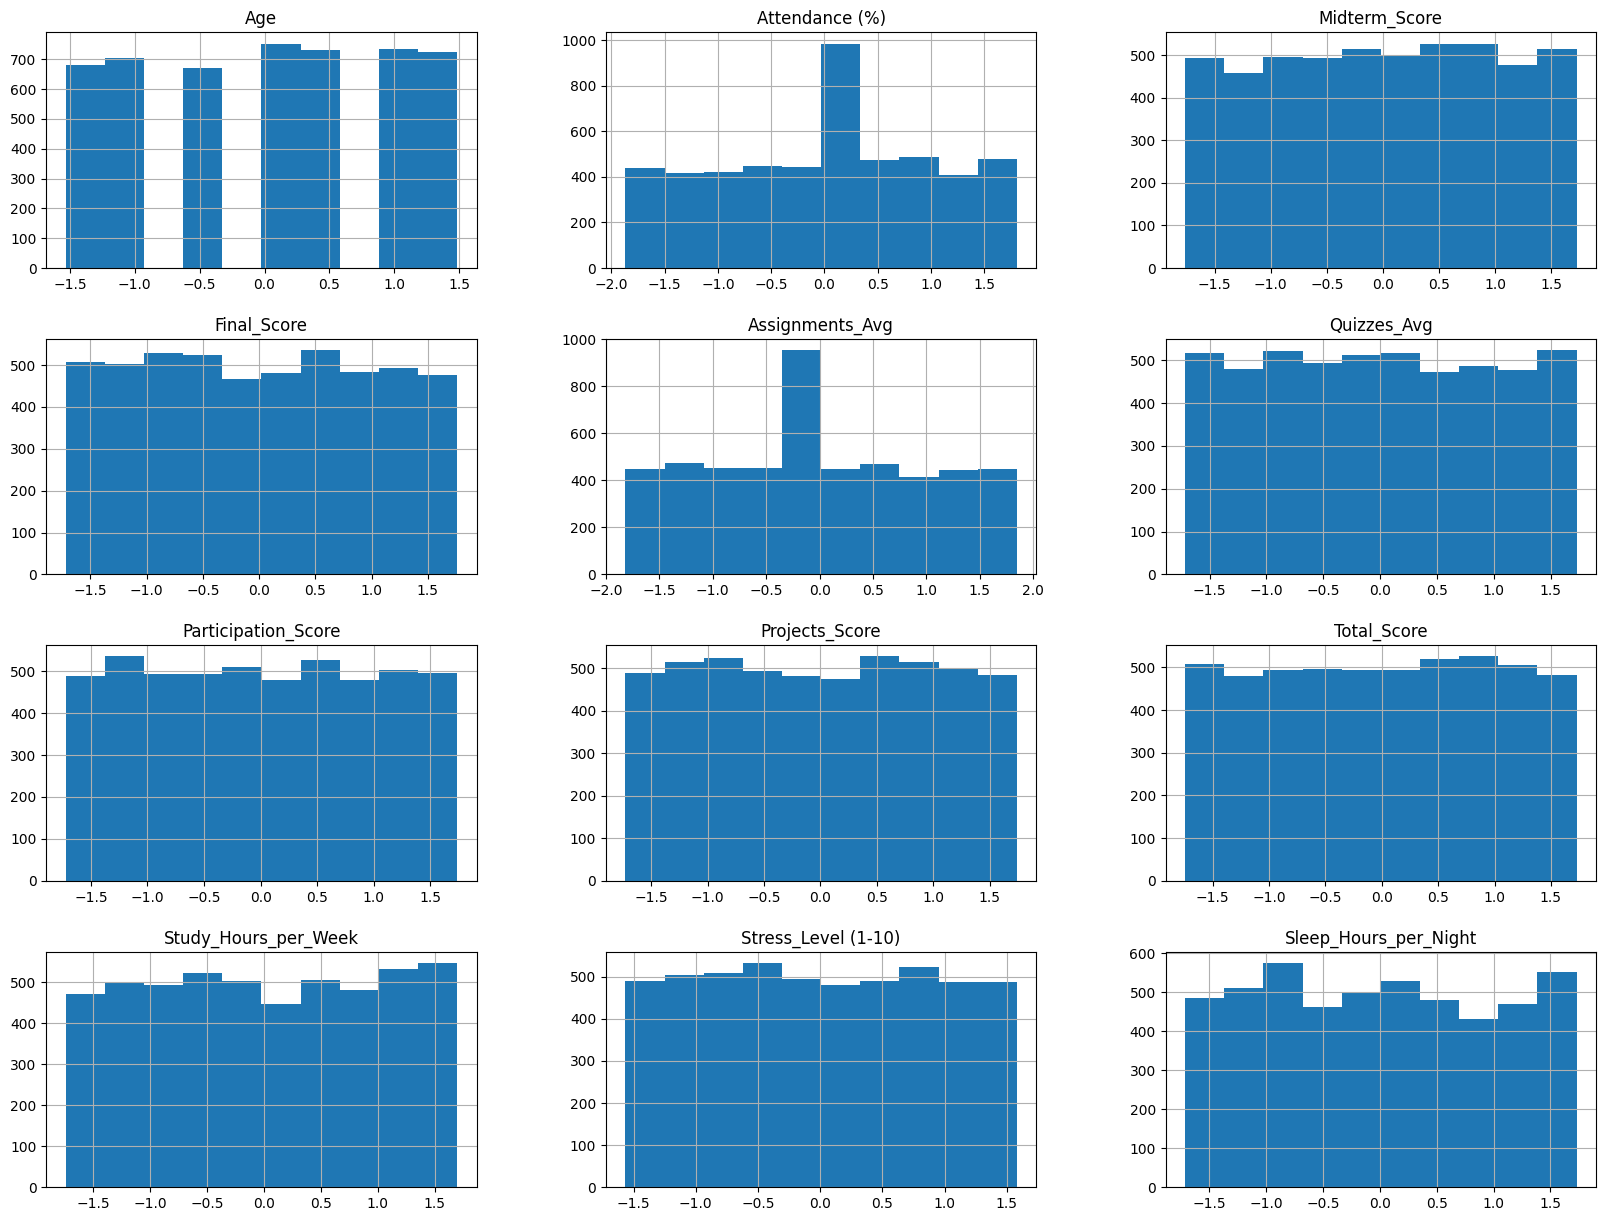

In [13]:
# plot a histogram for the numerical features
import matplotlib.pyplot as plt
df[num_features].hist(bins=10, figsize=(20,15))
plt.show()

#### _Variable importance_ 
-  it provides insights into which features are most influential in predicting the response variable. For Lasso and Ridge regression, the magnitude of regression coefficients can be a proxy for feature importance.
-   In the context of regularized regression, variables with larger absolute coefficients are more important.
- Lasso regression can shrink coefficients to zero, indicating that the corresponding feature is not important.
- Colinear predictors can mute each other's importance. We need to make sure we do not have multicollinear predictors.

#### _Regularization Techniques and Hyperparameters_

- Lasso, Ridge, and Elastic-Net introduce a penalty to the loss function. This penalty controls the complexity of the model, reducing the chance of overfitting.
- Key hyperparameters in these techniques include:

        - • a: Regularization strength. A higher value of a will impose a stronger penalty, potentially shrinking coefficients closer to zero.
        - • p: Mix ratio in Elastic-Net regression. Dictates the balance between Lasso and Ridge penalties

Techniques like grid search can help us find the optimal parameters.
Expect for the optimal penalty to be larger when there are more predictors.

![](../imgs/target.jpeg)

In [14]:
X=df[num_features].drop(columns="Final_Score")  
y = df["Final_Score"]

![](../imgs/dataSplit.jpg)

In [15]:
# تقسيم البيانات 
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X, y  ,test_size=.33, random_state=42)

###  Ridge  Model

$\Large  RSS_{Ridge}= \sum (Y_i -\hat Y_i )^2 + \alpha\sum\beta_i^2  $

$\Large  RSS_{Ridge}= \sum (Y_i -\beta_0 -\beta_iX_i )^2 + \alpha\sum\beta_i^2  $

![](../imgs/model.png)

In [ ]:
#  use RidgeCV to find the best alpha
from sklearn.linear_model import RidgeCV

alpha_array= np.linspace(0.01, 60, 200)
ridgeCV = RidgeCV(alphas=alpha_array , store_cv_results=True ).fit(
    X= X_test, y=y_test
)
ridgeCV.alpha_

np.float64(60.0)

In [17]:
X_train.keys()

Index(['Age', 'Attendance (%)', 'Midterm_Score', 'Assignments_Avg',
       'Quizzes_Avg', 'Participation_Score', 'Projects_Score', 'Total_Score',
       'Study_Hours_per_Week', 'Stress_Level (1-10)', 'Sleep_Hours_per_Night'],
      dtype='object')

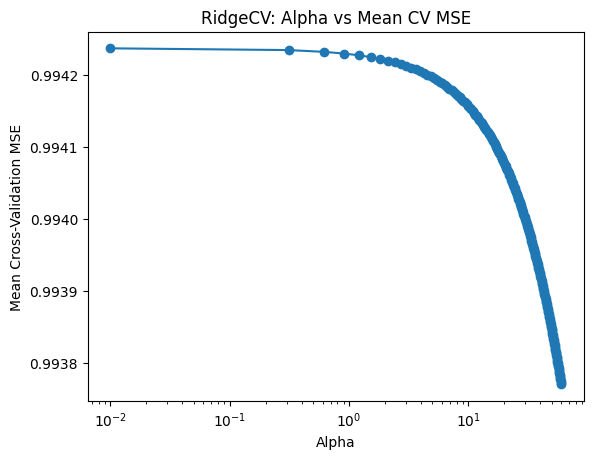

In [23]:
# Assuming ridgeCV is already fitted
# ridgeCV.mse_path_ contains the MSE for each alpha across folds
# mean_mse = np.mean(ridgeCV.mse_path_, axis=1)  # Mean MSE across folds for each alpha

mean_mse = ridgeCV.cv_results_.mean(axis=0)  # Mean MSE across folds for each alpha
# Plot alphas vs mean MSE
plt.plot(ridgeCV.alphas, mean_mse, marker='o')
plt.xlabel("Alpha")
plt.ylabel("Mean Cross-Validation MSE")
plt.title("RidgeCV: Alpha vs Mean CV MSE")
plt.xscale("log")  # Use log scale for alpha if applicable
plt.show()

#### How to Interpret the Curve:

##### Optimal Alpha:
The optimal value of alpha is the one that minimizes the mean cross-validation MSE. This is the point where the curve reaches its lowest value.
In your case, the optimal alpha is likely somewhere in the middle of the curve, where the MSE is lowest.
##### Underfitting (Left Side):
When alpha is too small, the model is under-regularized, and the MSE is higher because the model overfits the training data.

##### Overfitting (Right Side):
When alpha is too large, the model is over-regularized, and the MSE increases because the model underfits the data.


##### Recommendation 
Train the Final Model: Use the optimal alpha to train your Ridge regression model on the entire training set.
Evaluate on Test Data: Evaluate the model on the test set to check its performance.
Summary:

The curve helps you visualize the trade-off between underfitting and overfitting as you vary the regularization strength (alpha).
The goal is to find the alpha that minimizes the MSE, which balances the bias-variance trade-off and leads to the best generalization performance.

In [24]:
print("Optimal Alpha:", ridgeCV.alpha_)

Optimal Alpha: 60.0


In [27]:
# display features. ridgecv   names 
ridgeCV.feature_names_in_

array(['Age', 'Attendance (%)', 'Midterm_Score', 'Assignments_Avg',
       'Quizzes_Avg', 'Participation_Score', 'Projects_Score',
       'Total_Score', 'Study_Hours_per_Week', 'Stress_Level (1-10)',
       'Sleep_Hours_per_Night'], dtype=object)

In [28]:
# display in a datafram the coefficients of the model and the model ridgecv feature_name_in_
pd.DataFrame(
    {
        "feature_name": ridgeCV.feature_names_in_,
        "coefficient": ridgeCV.coef_
    }
).sort_values("coefficient", ascending=False)



,feature_name,coefficient
9,Stress_Level (1-10),0.026783
8,Study_Hours_per_Week,0.011603
6,Projects_Score,0.007247
0,Age,0.006645
10,Sleep_Hours_per_Night,0.001398
2,Midterm_Score,0.001312
4,Quizzes_Avg,-0.007192
7,Total_Score,-0.008230
3,Assignments_Avg,-0.009532
5,Participation_Score,-0.012428


## LassoCV

In [29]:
#process thourgh lassoCV with teh same X_test, y_test 
from sklearn.linear_model import LassoCV
alpha_array= np.linspace(0.01, 60, 200)
LassoCV= LassoCV(alphas=alpha_array , cv=5).fit(
    X= X_train, y=y_train
)
LassoCV.alpha_

np.float64(60.0)

![](../imgs/metrics.png)

In [19]:
ridgModel.coef_


array([153967.54184004,  94814.42818117,  98276.85818078,  59617.62543581])

In [22]:
# display the mean of the coefficients  of the  the Ridge model
ridgModel.coef_.mean()

np.float64(101669.1134094499)

In [26]:
# dislay the y intercept of the Ridge model
print(f'y intercept  :{ridgModel.intercept_:.3}    : y intercept of the Ridge model')

y intercept  :2.88e+04    : y intercept of the Ridge model


In [28]:
# make prediction using the Ridge model
y_pred = ridgModel.predict(X_test_scaled)

In [29]:
# rideg model score evaluation
from sklearn import metrics 
f' Score :  {metrics.r2_score(y_test, y_pred):.3}'

' Score :  0.637'

In [30]:
ridgModel.score(X_test_scaled, y_test)

0.6371039316346094

In [31]:
print(f' Score :  {metrics.mean_absolute_error(y_test, y_pred):.3}')

 Score :  3.03e+04


In [32]:
import numpy as np
f' RMSE :  {np.sqrt(metrics.mean_absolute_error(y_test, y_pred)):.3}'

' RMSE :  1.74e+02'

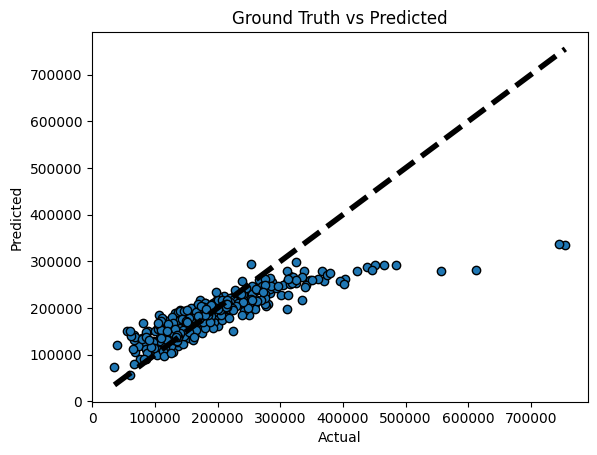

In [33]:
# plot the actual vs predicted values
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.scatter(y_test, y_pred, edgecolors=(0, 0, 0))
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=4)
ax.set_xlabel('Actual')
ax.set_ylabel('Predicted')
ax.set_title("Ground Truth vs Predicted")
plt.show()

In [114]:
# Import necessary libraries
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

# linRidge is your linear regression model (or Ridge if you're using regularization)
# X_train_scaled and y_train are your scaled training features and target

# Compute the learning curve
train_sizes, train_scores, test_scores = learning_curve(
    ridgeCV, X_train, y_train, cv=5, scoring="r2", n_jobs=-1, 
    train_sizes=np.linspace(0.1, 1.0, 10)  # Adjust train sizes (10 points from 10% to 100%)
)


In [115]:
# Calculate mean and standard deviation of training and test scores
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

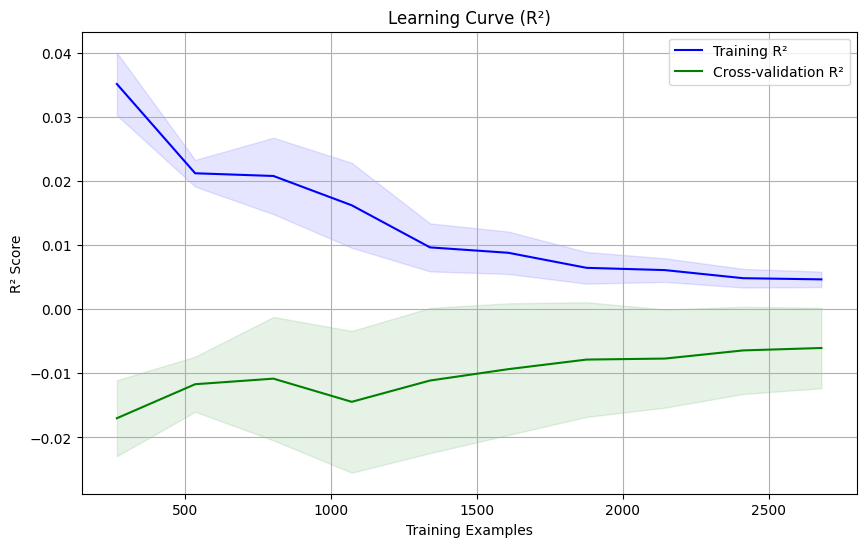

In [116]:
# Plot the learning curve
import numpy as np
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, label="Training R²", color="blue")
plt.plot(train_sizes, test_scores_mean, label="Cross-validation R²", color="green")

# Add shaded areas for standard deviation
plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, 
                 alpha=0.1, color="blue")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, 
                 alpha=0.1, color="green")

# Add labels and title
plt.xlabel("Training Examples")
plt.ylabel("R² Score")
plt.title("Learning Curve (R²)")
plt.legend(loc="best")
plt.grid(True)
plt.show()
